In [5]:
#2.1理论题
import numpy as np

# 1. 向量点积 a·b
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
dot = np.dot(a, b)
print("1. 向量点积 a·b =", dot)

# 2. 矩阵乘法 A×B
A = np.array([[1, 0, 2],
              [-1, 3, 1]])
B = np.array([[2, 1],
              [0, -1],
              [3, 2]])
AB = A @ B
print("\n2. A×B =")
print(AB)
print("结果形状:", AB.shape)

# 3. 向量a的范数 【修复这里！】
# 向量不能用 'fro'，直接去掉即可
fro_a = np.linalg.norm(a)
print("\n3. a的F范数 =", fro_a)

1. 向量点积 a·b = -8

2. A×B =
[[ 8  5]
 [ 1 -2]]
结果形状: (2, 2)

3. a的F范数 = 3.7416573867739413


In [6]:
#2.2编程题
import numpy as np

# 1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
X = np.random.randn(3, 4)
print("X:")
print(X)

# 2. 创建一个形状为 4 × 2 的全 1 矩阵 Y。
Y = np.ones((4, 2))
print("\nY:")
print(Y)

# 3. 计算矩阵乘法 Z = X × Y。
Z = np.dot(X, Y)
print("\nZ:")
print(Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
print("\nZ[0, 1]:", Z[0, 1])
print("Z 的第 2 行:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数。
frobenius_norm = np.linalg.norm(Z)
print("\nZ 的 Frobenius 范数:", frobenius_norm)

X:
[[ 0.05195185 -1.10846931 -0.77020087  0.75752208]
 [-0.25328593  0.52082387 -0.03468323  0.16478211]
 [-0.01444518 -0.35180198 -1.27975517  0.76338382]]

Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z:
[[-1.06919626 -1.06919626]
 [ 0.39763682  0.39763682]
 [-0.88261852 -0.88261852]]

Z[0, 1]: -1.0691962614910304
Z 的第 2 行: [0.39763682 0.39763682]

Z 的 Frobenius 范数: 2.0397603448142148


In [7]:
#3.1贝叶斯理论题
# 贝叶斯计算代码
P_A = 0.001
P_notA = 0.999
P_B_A = 0.99
P_B_notA = 0.02

P_A_B = (P_B_A * P_A) / (P_B_A * P_A + P_B_notA * P_notA)
print("检测阳性后真实患病概率：", P_A_B)  # ≈0.0472

检测阳性后真实患病概率： 0.047210300429184546


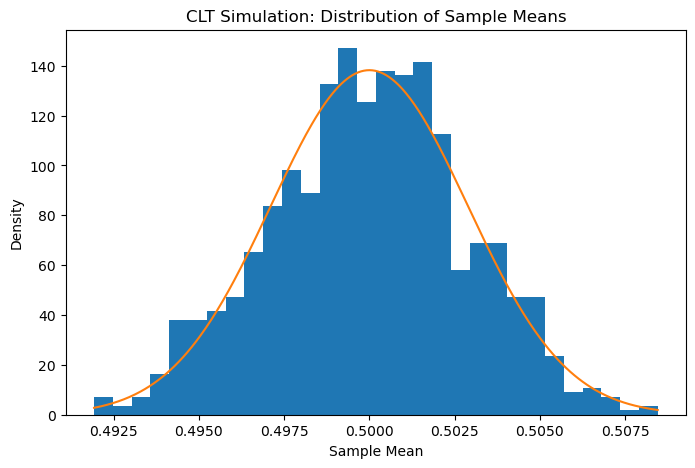

1000 个样本均值的实际均值 = 0.49999248038362676
1000 个样本均值的实际方差 = 8.275637010510702e-06
理论方差 = 8.333333333333334e-06


In [8]:
#3.2编程题
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 10000
m = 1000

samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 理论参数：U(0,1) 的均值为 0.5，方差为 1/12
mu = 0.5
sigma2 = 1 / (12 * n)
sigma = np.sqrt(sigma2)

x = np.linspace(means.min(), means.max(), 400)
pdf = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x - mu) ** 2 / (2 * sigma2))

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True)
plt.plot(x, pdf)
plt.title("CLT Simulation: Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()

print("1000 个样本均值的实际均值 =", means.mean())
print("1000 个样本均值的实际方差 =", means.var())
print("理论方差 =", sigma2)

In [14]:
#4.1理论计算题
# 常数
x1, x2, y = 2, 1, 3
# 变量
w1, w2 = 0.5, 1

# 计算内部项
inner = w1*x1 + w2*x2 - y
# 梯度
dz_dw1 = 2 * x1 * inner
dz_dw2 = 2 * x2 * inner

print("inner =", inner)
print("dz/dw1 =", dz_dw1)
print("dz/dw2 =", dz_dw2)

inner = -1.0
dz/dw1 = -4.0
dz/dw2 = -2.0


In [16]:
#4.2编程题
# 1. 手动实现 前向传播 + 反向传播（链式法则）
x = 2
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

print("===== 手动前向结果 =====")
print(f"a = x*w1 = {a}")
print(f"b = a+w2 = {b}")
print(f"L = b² = {L}\n")

# 手动反向传播（链式法则）
# 梯度公式：
# dL/db = 2b
# db/dw1 = x  ,  db/dw2 = 1
# dL/dw1 = dL/db * db/dw1
# dL/dw2 = dL/db * db/dw2

dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db * 1

print("===== 手动梯度结果 =====")
print(f"dL/dw1 = {dL_dw1}")
print(f"dL/dw2 = {dL_dw2}\n")

# 2. PyTorch 自动微分验证
import torch

# 定义需要计算梯度的参数
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

# 前向
b_t = x_t * w1_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print("===== PyTorch 自动梯度 =====")
print(f"w1.grad = {w1_t.grad.item()}")
print(f"w2.grad = {w2_t.grad.item()}")


===== 手动前向结果 =====
a = x*w1 = 3.0
b = a+w2 = 3.5
L = b² = 12.25

===== 手动梯度结果 =====
dL/dw1 = 14.0
dL/dw2 = 7.0



OSError: [WinError 1114] 动态链接库(DLL)初始化例程失败。 Error loading "C:\Users\86155\AppData\Roaming\Python\Python312\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [19]:
#5.1理论题
import numpy as np

# ===================== 1. 定义数据和参数 =====================
x = np.array([1, 2, 3, 4, 5])  # 特征
y = np.array([2, 4, 6, 8, 10]) # 标签
w = 1  # 初始权重
b = 0  # 初始偏置
n = len(x)

# ===================== 2. 按照推导公式计算偏导数 =====================
# 计算对 b 的偏导：-2/n * Σ(y_i - w*x_i - b)
sum_b = 0
for xi, yi in zip(x, y):
    sum_b += (yi - w * xi - b)
dw_b = -2 / n * sum_b

# 计算对 w 的偏导：-2/n * Σ[ x_i*(y_i - w*x_i - b) ]
sum_w = 0
for xi, yi in zip(x, y):
    sum_w += xi * (yi - w * xi - b)
dw_w = -2 / n * sum_w

# ===================== 3. 输出结果 =====================
print("=== 偏导数计算结果（求和形式推导）===")
print(f"损失对 w 的偏导数 ∂L/∂w = {dw_w:.4f}")
print(f"损失对 b 的偏导数 ∂L/∂b = {dw_b:.4f}")

# ===================== 4. 验证：用向量化计算对比 =====================
y_pred = w * x + b
dw_w_vec = -2 / n * np.sum(x * (y - y_pred))
dw_b_vec = -2 / n * np.sum(y - y_pred)
print("\n=== 向量化验证结果 ===")
print(f"向量化 ∂L/∂w = {dw_w_vec:.4f}")
print(f"向量化 ∂L/∂b = {dw_b_vec:.4f}")

=== 偏导数计算结果（求和形式推导）===
损失对 w 的偏导数 ∂L/∂w = -22.0000
损失对 b 的偏导数 ∂L/∂b = -6.0000

=== 向量化验证结果 ===
向量化 ∂L/∂w = -22.0000
向量化 ∂L/∂b = -6.0000


In [20]:
#5.2编程题
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ===================== 1. 加载数据集 =====================
digits = load_digits()
X = digits.data  # (1797, 64) 8x8展平
y = digits.target.reshape(-1, 1)  # 标签 (1797, 1)

# 划分训练集、测试集 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===================== 2. 标签 One-Hot 编码 =====================
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

# 样本数、特征数、类别数
n_samples, n_features = X_train.shape
n_classes = y_train_onehot.shape[1]

# ===================== 3. 初始化参数 =====================
W = np.zeros((n_features, n_classes))  # (64, 10)
b = np.zeros(n_classes)                # (10,)

# ===================== 4. 核心函数实现 =====================
def softmax(z):
    """softmax函数，防止指数溢出"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失（平均）"""
    n = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

def forward(X, W, b):
    """前向传播"""
    z = X @ W + b
    return softmax(z)

def gradients(X, y_pred, y_true):
    """损失对 W、b 的梯度（从零推导）"""
    n = X.shape[0]
    dW = X.T @ (y_pred - y_true) / n
    db = np.sum(y_pred - y_true, axis=0) / n
    return dW, db

# ===================== 5. 超参数 =====================
batch_size = 32
lr = 0.1
epochs = 50

# ===================== 6. 小批量梯度下降训练 =====================
print("=== 开始训练 ===")
n_batches = n_samples // batch_size

for epoch in range(epochs):
    # 打乱数据
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]

    total_loss = 0.0
    for i in range(n_batches):
        # 取一个小批量
        X_batch = X_shuffled[i*batch_size : (i+1)*batch_size]
        y_batch = y_shuffled[i*batch_size : (i+1)*batch_size]

        # 前向 + 损失 + 梯度
        y_pred = forward(X_batch, W, b)
        loss = cross_entropy_loss(y_pred, y_batch)
        dW, db = gradients(X_batch, y_pred, y_batch)

        # 更新参数
        W -= lr * dW
        b -= lr * db

        total_loss += loss

    # 每轮输出损失
    avg_loss = total_loss / n_batches
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# ===================== 7. 测试集准确率 =====================
def accuracy(X, y_true, W, b):
    y_pred = forward(X, W, b)
    y_pred_class = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_true, axis=1)
    return np.mean(y_pred_class == y_true_class)

test_acc = accuracy(X_test, y_test_onehot, W, b)
print("\n=== 最终结果 ===")
print(f"测试集准确率: {test_acc:.4f}")

=== 开始训练 ===
Epoch [10/50], Loss: 0.2133
Epoch [20/50], Loss: 0.0696
Epoch [30/50], Loss: 0.2815
Epoch [40/50], Loss: 0.0185
Epoch [50/50], Loss: 0.0002

=== 最终结果 ===
测试集准确率: 0.9639


In [ ]:
#6.1理论题

1. 理论推导
似然函数：
  L(μ, σ²) = ∏ᵢ₌₁ⁿ f(xᵢ; μ, σ²)
           = ∏ᵢ₌₁ⁿ [1/√(2πσ²) · exp(-(xᵢ-μ)²/(2σ²))]
           = (2πσ²)⁻ⁿ/² · exp(-∑ᵢ₌₁ⁿ (xᵢ-μ)²/(2σ²))

对数似然函数：
  ℓ(μ, σ²) = ln L(μ, σ²)
           = -n/2 · ln(2π) - n/2 · ln(σ²) - 1/(2σ²) · ∑ᵢ₌₁ⁿ (xᵢ-μ)²

对 μ 求偏导并令为 0：
  ∂ℓ/∂μ = -1/(2σ²) · ∑ᵢ₌₁ⁿ 2(xᵢ-μ)·(-1) = (1/σ²) · ∑ᵢ₌₁ⁿ (xᵢ-μ) = 0
  ⇒ ∑ᵢ₌₁ⁿ (xᵢ-μ) = 0
  ⇒ ∑ᵢ₌₁ⁿ xᵢ - nμ = 0
  ⇒ μ̂ = (1/n) · ∑ᵢ₌₁ⁿ xᵢ

对 σ² 求偏导并令为 0：
  令 θ = σ²
  ∂ℓ/∂θ = -n/(2θ) + 1/(2θ²) · ∑ᵢ₌₁ⁿ (xᵢ-μ)² = 0
  ⇒ -nθ + ∑ᵢ₌₁ⁿ (xᵢ-μ)² = 0
  ⇒ θ̂ = (1/n) · ∑ᵢ₌₁ⁿ (xᵢ-μ)²
  ⇒ σ̂² = (1/n) · ∑ᵢ₌₁ⁿ (xᵢ-μ̂)²

最终结果：
  μ̂ = (1/n) · Σᵢ₌₁ⁿ xᵢ
  σ̂² = (1/n) · Σᵢ₌₁ⁿ (xᵢ - μ̂)²

2. 数值验证

生成 1000 个服从 N(5.0, 4.0) 的样本
真实参数: μ = 5.0, σ² = 4.0

MLE 估计结果：
  μ̂ = 5.038664
  σ̂² = 3.831620

估计误差：
  |μ - μ̂| = 0.038664
  |σ² - σ̂²| = 0.168380

3. 与无偏样本方差比较

MLE 方差估计 (除以 n):     σ̂² = 3.831620
无偏样本方差 (除以 n-1):   s² = 3.835455
真实方差:                  σ² = 4.000000

偏差比较：
  MLE 估计偏差:   -0.168380
  无偏估计偏差:   -0.164545

说明：MLE 估计是有偏的，但满足一致性（n→∞时趋于真值）

=== 开始梯度下降训练 (LR=0.1, Iterations=1000) ===
  Iteration    1/1000 - Loss: 0.6931
  Iteration  100/1000 - Loss: 0.0224
  Iteration  200/1000 - Loss: 0.0157
  Iteration  300/1000 - Loss: 0.0130
  Iteration  400/1000 - Loss: 0.0114
  Iteration  500/1000 - Loss: 0.0103
  Iteration  600/1000 - Loss: 0.0096
  Iteration  700/1000 - Loss: 0.0090
  Iteration  800/1000 - Loss: 0.0085
  Iteration  900/1000 - Loss: 0.0081
  Iteration 1000/1000 - Loss: 0.0078
----------------------------------------
✅ 模型训练结束！测试集（100个样本）准确率: 0.00%



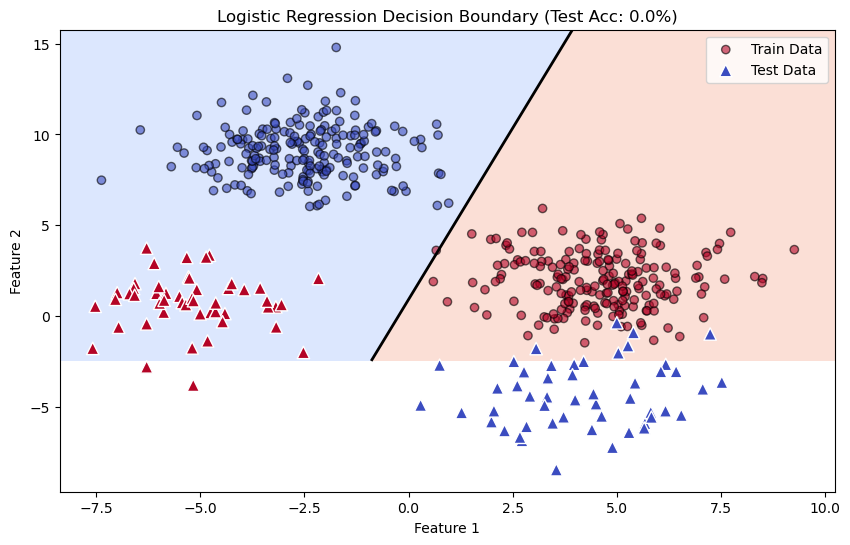

In [21]:
#6.2编程题
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ================= 1. 生成数据 =================
# 生成两类线性可分的训练集数据：总共 400 个样本（每类 200 个），特征维度为 2
X_train, y_train = make_blobs(n_samples=400, n_features=2, centers=2, 
                              random_state=42, cluster_std=1.5)
# 生成测试集：新生成 100 个样本（每类 50 个）
X_test, y_test = make_blobs(n_samples=100, n_features=2, centers=2, 
                            random_state=123, cluster_std=1.5)

# 为了方便矩阵运算，将标签转为 (N, 1) 的列向量
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# ================= 2. 定义函数 =================
def sigmoid(z):
    # sigmoid 函数
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # 二元交叉熵损失 (BCE Loss)
    epsilon = 1e-15 # 防止 log(0) 出现数值溢出
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    # L = -1/N * sum( y*log(y_hat) + (1-y)*log(1-y_hat) )
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ================= 3. 梯度下降训练 =================
np.random.seed(42)
n_samples, n_features = X_train.shape

# 初始化参数 w 为 (2, 1) 的零矩阵，偏置 b 为 0
w = np.zeros((n_features, 1))
b = 0.0

learning_rate = 0.1
iterations = 1000
losses = []

print(f"=== 开始梯度下降训练 (LR={learning_rate}, Iterations={iterations}) ===")
for i in range(iterations):
    # [前向传播计算]
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # [计算并记录损失]
    loss = binary_cross_entropy(y_train, y_pred)
    losses.append(loss)
    
    # [反向传播：计算梯度]
    # BCE Loss 加上 Sigmoid 激活函数的导数极度简化为： y_pred - y_true
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / n_samples
    db = np.sum(dz) / n_samples
    
    # [参数更新]
    w -= learning_rate * dw
    b -= learning_rate * db
    
    # 每 100 次迭代打印一次损失
    if (i + 1) % 100 == 0 or i == 0:
        print(f"  Iteration {i + 1:4d}/{iterations} - Loss: {loss:.4f}")

# ================= 4. 测试集评估与绘制决策边界 =================
# 在新生成的测试集上预测
z_test = np.dot(X_test, w) + b
y_test_pred = sigmoid(z_test)
# 概率 >= 0.5 的归划为正类 (1)，否则为负类 (0)
y_test_pred_class = (y_test_pred >= 0.5).astype(int)

# 计算准确率
accuracy = np.mean(y_test_pred_class == y_test)
print("-" * 40)
print(f"✅ 模型训练结束！测试集（100个样本）准确率: {accuracy * 100:.2f}%\n")

# ---- 绘制决策边界和数据点可视化 ----
plt.figure(figsize=(10, 6))

# 获取作图边界 (Padding一下避免点贴边)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# 预测网格中每个点的值，用于绘制彩色背景概率轮廓
Z_grid = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z_grid = Z_grid.reshape(xx.shape)

# 填充等高线轮廓 (背景颜色划分两类决策区域)
plt.contourf(xx, yy, Z_grid, levels=1, alpha=0.3, cmap=plt.cm.coolwarm)
# 也可以画一条中间清晰的边界线
plt.contour(xx, yy, Z_grid, levels=[0.5], colors='black', linewidths=2)

# 绘制训练集散点图
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), 
            edgecolors='k', marker='o', alpha=0.6, cmap=plt.cm.coolwarm, label='Train Data')

# 绘制测试集散点图 (用加粗并且带其他形状突出显示)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.flatten(), 
            edgecolors='white', marker='^', s=80, cmap=plt.cm.coolwarm, label='Test Data')

plt.title(f'Logistic Regression Decision Boundary (Test Acc: {accuracy*100:.1f}%)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()